## İnitialization and Data Loading


In [2]:
import pandas as pd
import numpy as np
df=pd.read_csv('D:\\d_projects\\Bir_market\\products.csv')



### Data Information

In [3]:
print(df.shape)
print(df.info())
print(df.sample(5))


(2367, 5)
<class 'pandas.DataFrame'>
RangeIndex: 2367 entries, 0 to 2366
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       2367 non-null   str  
 1   new_price  1980 non-null   str  
 2   old_price  2367 non-null   str  
 3   rating     2367 non-null   str  
 4   discount   2367 non-null   str  
dtypes: str(5)
memory usage: 92.6 KB
None
                                                   name new_price   old_price  \
2304                Qabyuyan maşın Whirlpool WFE 2B19 X  968.54 ₼  1 122.99 ₼   
353   Paltaryuyan maşın Shivaki _MYCM_14_TG70F 7 kq ...  215.04 ₼    299.98 ₼   
2050                           Soyuducu Pozis RK149W Ağ  858.99 ₼  1 399.99 ₼   
1939                            Soyuducu Konka 514 DX02  899.99 ₼  1 299.99 ₼   
75    Soyuducu Biryusa 416, kompakt dondurucu, ağ, m...  465.00 ₼    719.00 ₼   

              rating discount  
2304  reytinq yoxdur    -14 %  
353   reytinq yoxdur    -28 %  
2050

In [4]:
df.isnull().sum()

name           0
new_price    387
old_price      0
rating         0
discount       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(37)

In [6]:
df=df.drop_duplicates()
df.shape

(2330, 5)

### Fixing Data

In [7]:
df.dtypes

name         str
new_price    str
old_price    str
rating       str
discount     str
dtype: object

In [8]:
df['new_price'] = df['new_price'].str.replace('₼', '').str.replace(' ', '').str.strip().astype(float)
df['old_price'] = df['old_price'].str.replace('₼', '').str.replace(' ', '').str.strip().astype(float)
df['rating_score'] = df['rating'].astype(str).str.extract(r'(\d+\.\d+)').astype(float)
df['rating_count'] = df['rating'].astype(str).str.extract(r'(\d+)\s+reytinq').astype(float).fillna(0).astype(int)
df = df.drop(columns=['rating'])

In [9]:
brands = ['Beko', 'Samsung', 'LG', 'Bosch', 'Artel', 'Midea', 'Lanova', 
          'Biryusa', 'Shivaki', 'Hoffmann', 'Eurolux', 'Indesit', 'Whirlpool',
          'Hisense', 'Haier', 'Candy', 'Hotpoint', 'Siemens', 'Electrolux',
          'Sharp', 'Winning Star', 'Hitachi', 'Bompan', 'Vestel', 'Finlux', 
          'Ugur', 'Eurostyle', 'Atlant','Ardesto',' RAF','Yoshiro',' Pozis','Ziffler','Hitachi','Eurostyle',
            'Gefest','Tessa', 'Kraft','Vesta','Portativ','Hoffman','ZISHUU','7Tech','Toshiba',
            'Zhendah','Wolf','Darkin','Uğur','SISO','DSP','Ezel','Vegas',' Luxell',
            'Silver','Vestfrost','Alneo','Vermont','Smeg','Taube','YOSHIRO','No Frost',
            'Boma','Yücel','Quicks','Lotus','Regal','Premier','Snow Village','CASO']




def extract_brand(name):
    for brand in brands:
        if brand.lower() in name.lower():
            return brand
    return 'No brand'

df['brand'] = df['name'].apply(extract_brand)
print(df['brand'].value_counts())

brand
No brand    361
Biryusa     254
Eurolux     156
Shivaki     150
LG          134
           ... 
Vermont       2
Tessa         1
Ezel          1
Boma          1
ZISHUU        1
Name: count, Length: 65, dtype: int64


In [10]:
def discount_refresh(discount):
    if discount == 'endirim yoxdur':
        return 0
    else:
        return float(discount.replace('%', '').replace(' ', '').replace('-', '').strip())

df['discount'] = df['discount'].apply(discount_refresh)
df.head(5)

,name,new_price,old_price,discount,rating_score,rating_count,brand
0,Paltaryuyan maşın Lanova LNVWM-60-WW,409.00,789.00,48.0,4.8,58,Lanova
1,Soyuducu Beko B1RCNK272G,727.98,944.99,23.0,4.5,48,Beko
2,Paltaryuyan maşın Lanova LNVWM-60-TT,433.00,799.00,46.0,4.7,18,Lanova
3,Soyuducu Midea MDRB424FGF02O,858.93,1199.90,28.0,3.7,3,Midea
4,Soyuducu Biryusa W920NF,675.00,1059.00,36.0,4.9,23,Biryusa


In [11]:
def rating_score_refresh(rating_score):
    if pd.isna(rating_score):
        return 0
    else:
        return float(str(rating_score).replace(' ', '').strip())

df['rating_score'] = df['rating_score'].apply(rating_score_refresh)

In [12]:
df['new_price'] = df['new_price'].fillna(df['old_price'])

In [13]:
cat_keywords = {
    'Soyuducu': 'Soyuducu',
    'Paltaryuyan': 'Paltaryuyan maşın',
    'Dondurucu': 'Dondurucu',
    'Qabyuyan': 'Qabyuyan maşın',
    'Qaz': 'Qaz plitəsi',
    'Mini': 'Mini soyuducu',
    'Buz': 'Buz generatoru',
    'Quruducu': 'Quruducu',
    'Ticarət': 'Ticarət soyuducusu',
    'Paltar': 'Paltar qurudan',
    'Elektrik': 'Elektrik plitəsi',
    'Şərab': 'Şərab dolabı'
}

def extract_category(name):
    first_word = name.split()[0]
    return cat_keywords.get(first_word, 'Digər')

df['category'] = df['name'].apply(extract_category)
print(df['category'].value_counts())

category
Soyuducu              893
Paltaryuyan maşın     535
Dondurucu             289
Digər                 145
Qabyuyan maşın        130
Qaz plitəsi           102
Mini soyuducu          74
Buz generatoru         66
Quruducu               40
Ticarət soyuducusu     25
Paltar qurudan         17
Elektrik plitəsi        7
Şərab dolabı            7
Name: count, dtype: int64


In [14]:
df=df.reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2330 entries, 0 to 2329
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          2330 non-null   str    
 1   new_price     2330 non-null   float64
 2   old_price     2330 non-null   float64
 3   discount      2330 non-null   float64
 4   rating_score  2330 non-null   float64
 5   rating_count  2330 non-null   int64  
 6   brand         2330 non-null   str    
 7   category      2330 non-null   str    
dtypes: float64(4), int64(1), str(3)
memory usage: 145.8 KB


In [15]:
df.to_csv('cleaned_products.csv', index=False)

### Exploratory Data Analysis


In [16]:
df.tail(10)

,name,new_price,old_price,discount,rating_score,rating_count,brand,category
2320,"Quruducu maşın Hoffman, DMH8030X, 8 kq, Ön, Boz",739.99,939.99,21.0,0.0,0,Hoffman,Quruducu
2321,"Soyuducu Shivaki H345-RND, ikiqapılı, gümüşü",599.99,999.99,40.0,0.0,0,Shivaki,Soyuducu
2322,Soyuducu LG F40BG No Frost dördqapılı qara,2999.00,3999.00,25.0,0.0,0,LG,Soyuducu
2323,"Soyuducu Shivaki HD-276-FN, ikiqapılı, qara",475.98,899.99,47.0,0.0,0,Shivaki,Soyuducu
2324,"Soyuducu Shivaki HD 316-FN, statik, ikiqapılı,...",514.98,899.99,43.0,0.0,0,Shivaki,Soyuducu
2325,"Soyuducu Shivaki H345-RND, ikiqapılı, ağ",582.99,999.99,42.0,0.0,0,Shivaki,Soyuducu
2326,Paltaryuyan maşın Eurolux EU-WM1273S-8BLDG 8 k...,650.59,884.99,26.0,0.0,0,Eurolux,Paltaryuyan maşın
2327,"Soyuducu Hisense RD39WCR, Inox",848.99,1799.99,53.0,0.0,0,Hisense,Soyuducu
2328,Soyuducu Pozis RK 103 Silver,789.68,1400.00,44.0,0.0,1,Pozis,Soyuducu
2329,Soyuducu Hoffmann DTF-840WEN,319.70,700.00,54.0,0.0,0,Hoffmann,Soyuducu


#### Product Count by Category

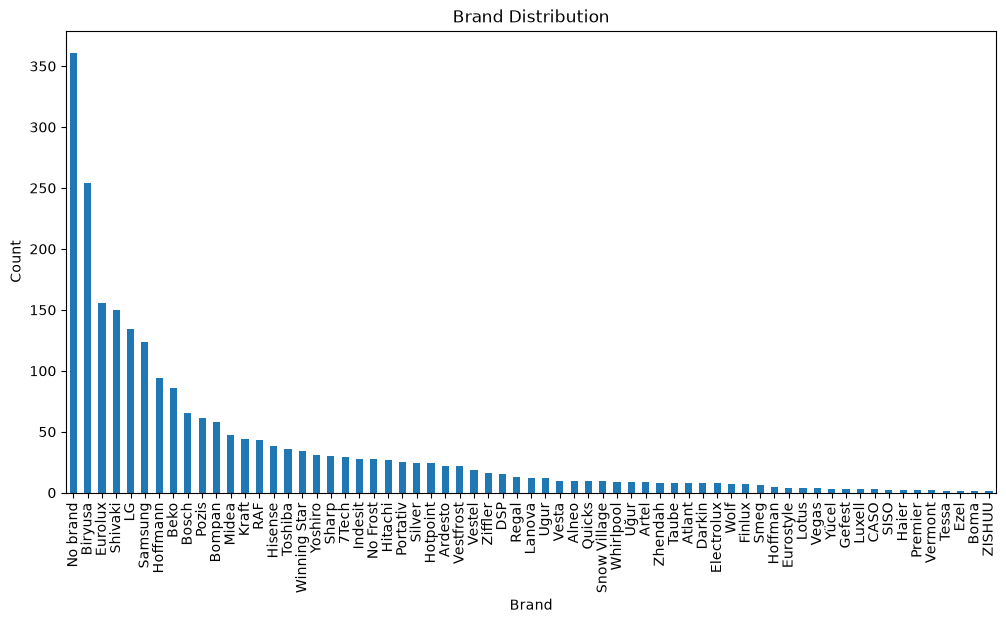

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df['brand'].value_counts().plot(kind='bar',figsize=(12,6))
plt.title('Brand Distribution')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.show()

Biryusa leads the market with the highest product count, while a large portion of products belong to no-brand manufacturers.

#### Average Price by Category

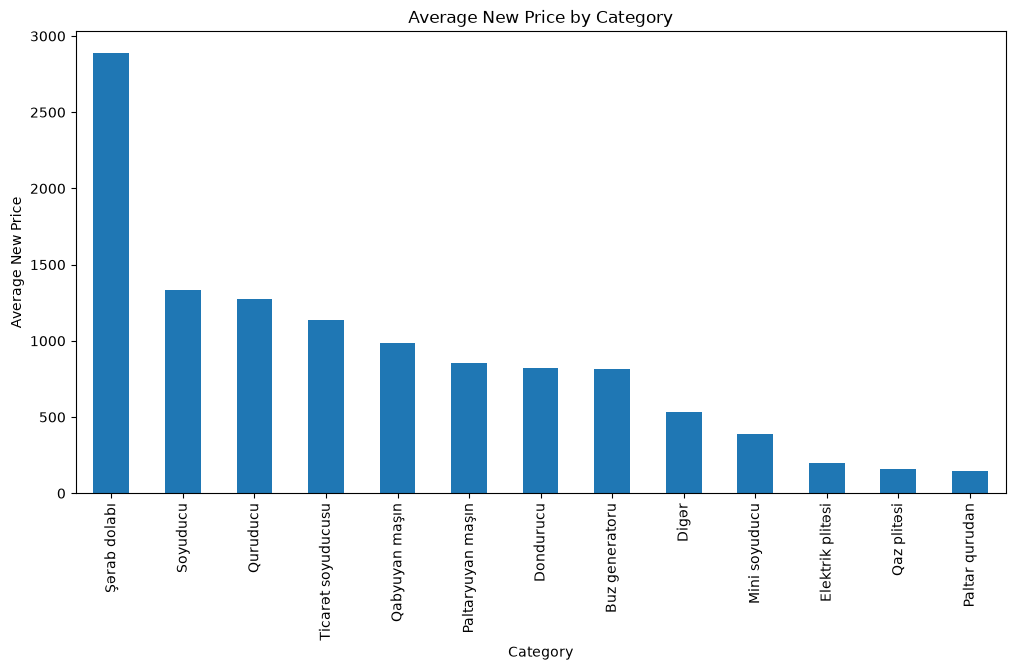

In [18]:
df.groupby('category')['new_price'].mean().sort_values(ascending=False).plot(kind='bar',figsize=(12,6))

plt.title('Average New Price by Category')
plt.xlabel('Category')
plt.ylabel('Average New Price')
plt.show()

Wine cabinets dominate in average price at approximately 2800 AZN, which is nearly twice the price of the second highest category — refrigerators at around 1300-1400 AZN.

#### Top Brand by Category

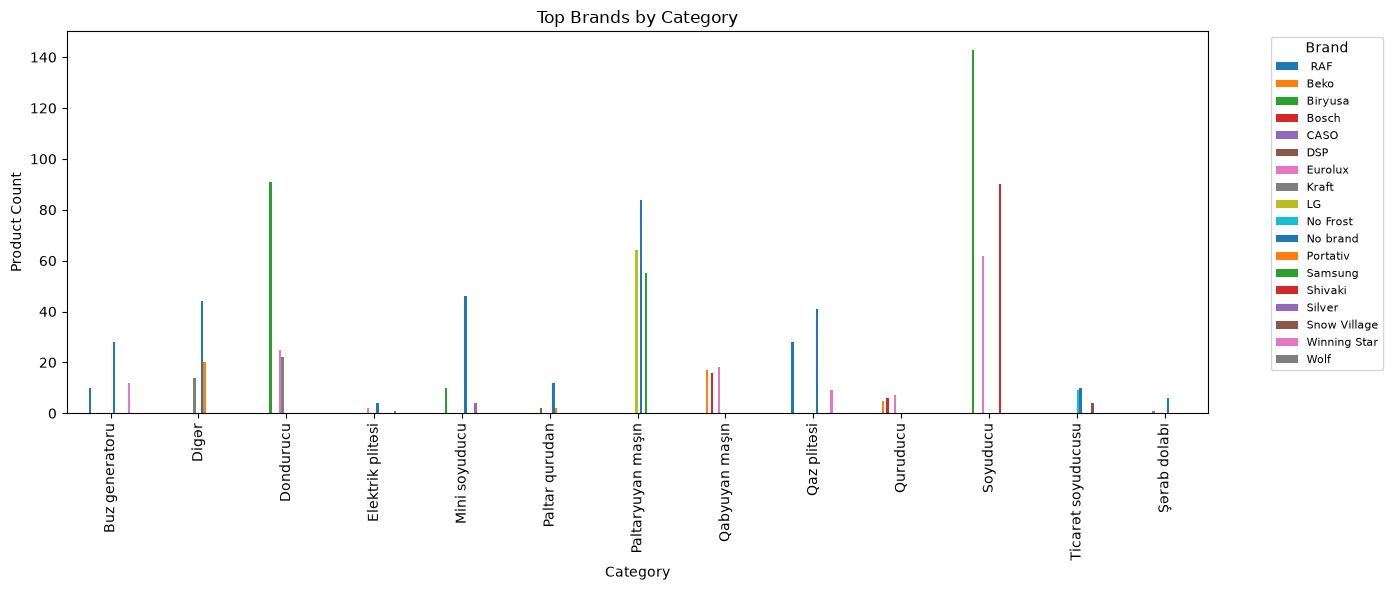

In [19]:
top_brands = df.groupby(['category', 'brand'])['name'].count().reset_index()
top_brands = top_brands.sort_values('name', ascending=False).groupby('category').head(3)

top_brands.pivot(index='category', columns='brand', values='name').plot(kind='bar', figsize=(14, 6))
plt.title('Top Brands by Category')
plt.xlabel('Category')
plt.ylabel('Product Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title='Brand')
plt.tight_layout()
plt.show()

Biryusa dominates in refrigerators and freezers, while Eurolux leads in dryers and dishwashers. Other categories show a relatively balanced brand distribution.

### Average Discount and Rating by Category

In [20]:
df.groupby('category').agg({'discount': 'mean', 'rating_score': 'mean'})

,discount,rating_score
category,,
Buz generatoru,18.863636,0.000000
Digər,23.724138,0.344138
Dondurucu,29.906574,0.296194
Elektrik plitəsi,32.714286,0.000000
Mini soyuducu,26.905405,0.228378
Paltar qurudan,34.000000,0.282353
Paltaryuyan maşın,29.050467,0.514393
Qabyuyan maşın,29.392308,0.343846
Qaz plitəsi,23.343137,0.345098


Paltar qurudan and elektrik plitəsi lead in average discount (~34%), while şərab dolabı and ticarət soyuducusu have the lowest discounts (~6-7%). Paltaryuyan maşın has the highest average rating score (0.51), whereas buz generatoru, elektrik plitəsi and şərab dolabı have no ratings at all.

### Brand Performance Overview

In [21]:
df.groupby('brand').agg(
    product_count=('name', 'count'),
    average_price=('new_price', 'mean'),
    average_discount=('discount', 'mean'),
    average_rating=('rating_score', 'mean'),
    average_rating_count=('rating_count', 'mean')
).sort_values('product_count', ascending=False)

,product_count,average_price,average_discount,average_rating,average_rating_count
brand,,,,,
No brand,361,600.967812,24.911357,0.182271,0.645429
Biryusa,254,691.247756,31.539370,0.531890,1.681102
Eurolux,156,1066.075128,28.506410,0.119231,0.307692
Shivaki,150,518.524533,36.720000,0.122667,0.333333
LG,134,1959.350000,28.552239,0.420149,2.716418
...,...,...,...,...,...
Premier,2,874.495000,42.000000,0.000000,0.000000
Ezel,1,29.000000,61.000000,4.400000,27.000000
Boma,1,176.980000,41.000000,0.000000,0.000000


Biryusa dominates with 254 products and a solid average rating of 0.53, making it the strongest brand overall. LG positions itself as a premium brand with the highest average price at 1959 AZN. Shivaki offers the most competitive discounts at 36.7% on average. Ezel stands out with the highest rating score (4.4), though it has only one product in the dataset.

### Price Distribution

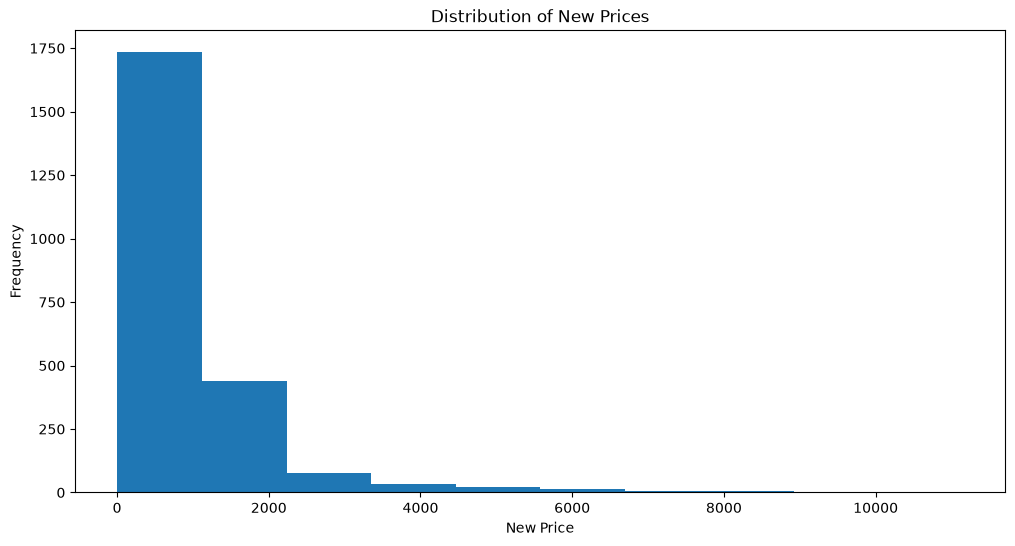

In [22]:
df['new_price'].plot(kind='hist', figsize=(12, 6))
plt.title('Distribution of New Prices')
plt.xlabel('New Price') 
plt.show()

The majority of products are priced between 0-1000 AZN, with frequency dropping sharply beyond 2000 AZN. A small number of premium products exceed 6000 AZN, indicating a right-skewed price distribution.

### Discount Distribution

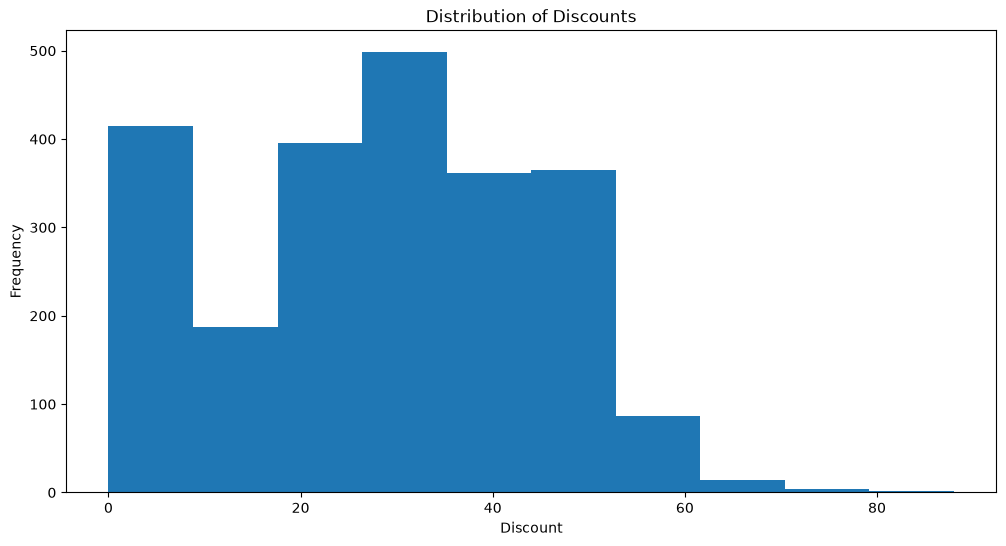

In [23]:
df['discount'].plot(kind='hist', figsize=(12, 6))
plt.title('Distribution of Discounts')
plt.xlabel('Discount')
plt.show()

Discounts are most concentrated in the 20-50% range, with a peak around 25-35%. A significant number of products have no discount (0%), while very few exceed 60% discount.

### Price vs Discount

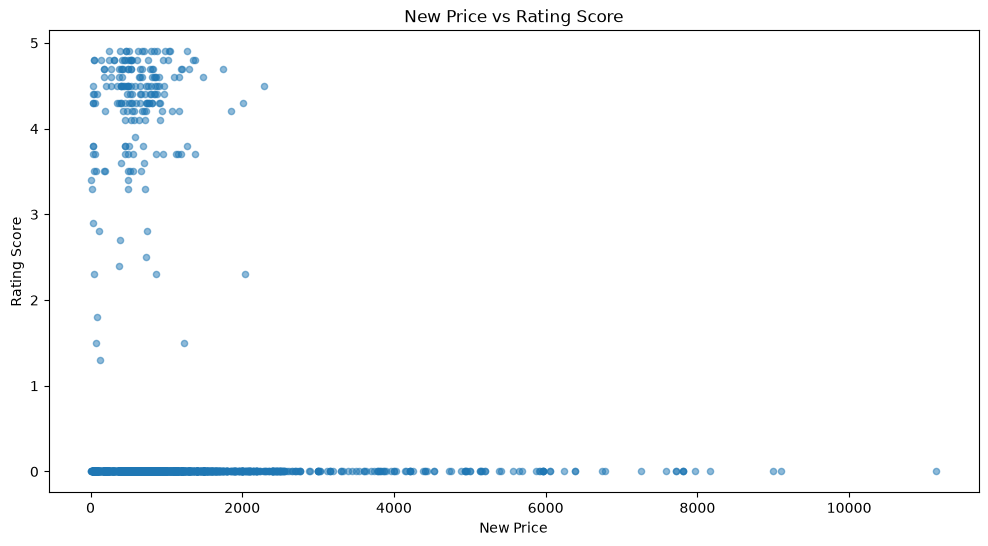

In [24]:
df.plot(kind='scatter', x='new_price', y='rating_score', alpha=0.5, figsize=(12, 6))
plt.title('New Price vs Rating Score')
plt.xlabel('New Price')
plt.ylabel('Rating Score')
plt.show()

Most rated products are concentrated in the 0-1000 AZN price range with high rating scores (4.0-5.0), suggesting budget-friendly products receive more customer reviews. Premium products above 2000 AZN have little to no ratings, indicating lower customer engagement at higher price points.

### Price Range by Category

In [25]:
expensive_products = df.groupby('category').agg(max_price=('new_price', 'max')).sort_values('max_price', ascending=False)
cheapest_products = df.groupby('category').agg(min_price=('new_price', 'min')).sort_values('min_price', ascending=True)

pd.concat([expensive_products, cheapest_products], axis=1)

,max_price,min_price
category,,
Soyuducu,11150.00,160.00
Buz generatoru,8162.00,19.99
Qaz plitəsi,7963.00,18.73
Dondurucu,7251.15,177.27
Paltaryuyan maşın,6058.62,39.09
Şərab dolabı,5689.00,931.00
Digər,5574.00,4.99
Mini soyuducu,4152.00,9.99
Quruducu,3811.00,50.85


Refrigerators have the widest price range (160-11150 AZN), indicating a broad market from budget to premium. Wine cabinets have the narrowest range (931-5689 AZN), suggesting they target a more specific customer segment. Ice generators and gas stoves show surprisingly high maximum prices despite having very low entry-level prices.

### Top 10 Highest Rated Products

In [26]:
df[['name', 'rating_score']].sort_values('rating_score', ascending=False).head(10)

,name,rating_score
2255,Soyuducu Hoffmann DFT-167S,4.9
1066,Soyuducu Samsung RB31FERNDWW/WT,4.9
90,Soyuducu Hisense DT27DR4 W - DT27DR4 W,4.9
257,Dondurucu şkaf Biryusa M6147NF Metal,4.9
1998,Soyuducu Indesit ITS 4160 W,4.9
540,Paltaryuyan maşın LG F2V5HYLYJ.AMBPMER,4.9
490,Paltaryuyan maşın Samsung WW80AGAS21AXLP,4.9
281,Soyuducu Indesit DS 4180 G,4.9
30,Paltaryuyan maşın Midea MF100W60/W-C,4.9
567,Soyuducu Beko B5RCNK363ZXBR,4.9


The top 10 highest rated products all share a perfect score of 4.9, making it difficult to differentiate quality based on rating score alone. Rating count would be a more reliable indicator of product quality and popularity

### Rating Score vs Rating Count

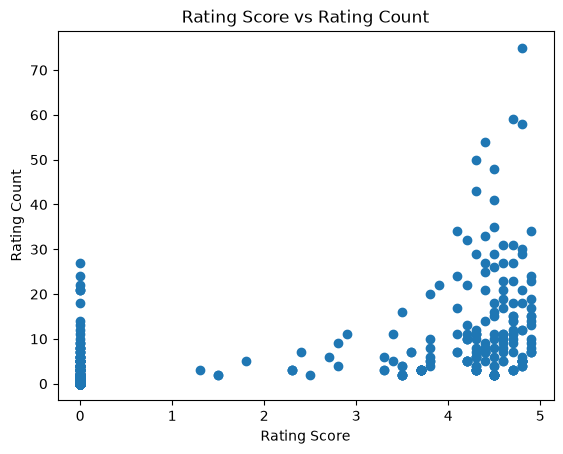

In [27]:
plt.scatter(df['rating_score'], df['rating_count'])
plt.title('Rating Score vs Rating Count')
plt.xlabel('Rating Score')
plt.ylabel('Rating Count')
plt.show()

Products with higher rating scores (4.0-5.0) tend to have significantly more reviews, suggesting that quality products attract more customer engagement. The majority of products have a rating score of 0, indicating they have not yet received any reviews.

### Discount vs Rating Score

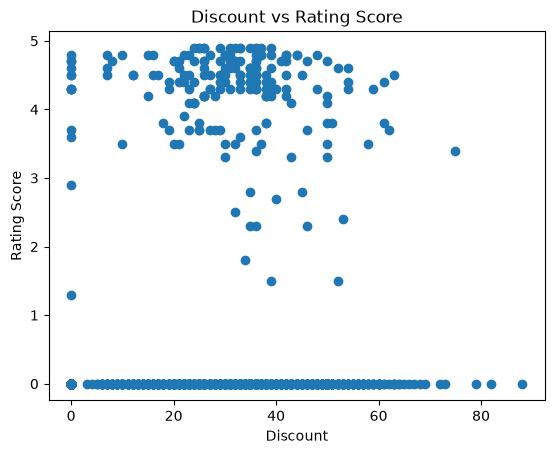

In [28]:
plt.scatter(df['discount'], df['rating_score'])
plt.title('Discount vs Rating Score')
plt.xlabel('Discount')
plt.ylabel('Rating Score')
plt.show()

There is no clear correlation between discount percentage and rating score. High-rated products (4.0-5.0) appear across all discount ranges, suggesting that discounts do not significantly influence customer satisfaction ratings.

### Correlation Analysis

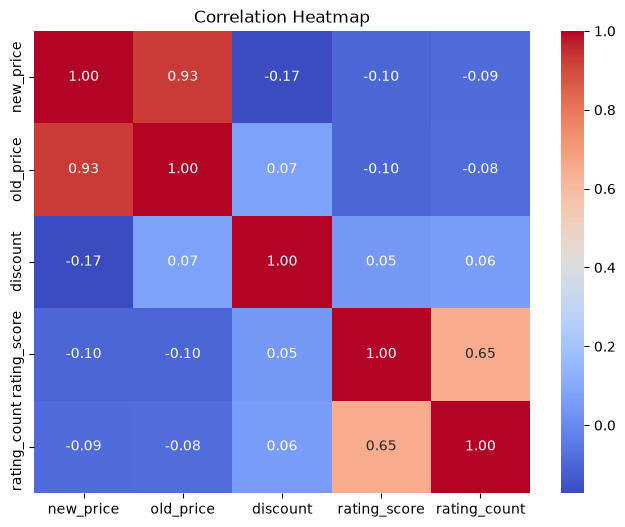

In [29]:
corr = df[['new_price', 'old_price', 'discount', 'rating_score', 'rating_count']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### A/B Testing

In [30]:
from scipy import stats

group_a = df[df['category'] == 'Soyuducu']['new_price']
group_b = df[df['category'] == 'Qabyuyan maşın']['new_price']

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0 — significant difference!")
else:
    print("Fail to Reject H0 — no significant difference!")

T-statistic: 3.1473
P-value: 0.0017
Reject H0 — significant difference!


The t-test reveals a statistically significant price difference between refrigerators and dishwashers (p-value: 0.0017 < 0.05). We reject the null hypothesis, confirming that refrigerators are significantly more expensive than dishwashers on average.